# Week 2 — Notebook 2: Technical Indicators

Implement **10 technical indicators** from scratch using only `pandas` and `numpy`.
No `ta`, `ta-lib`, or similar libraries — every value must come from the OHLCV columns.

These features are what the LSTM model will consume in later weeks.
The final cell saves a complete feature CSV to `data/processed/`.

> Implement every TODO using the mathematical formula given.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0. Setup

In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR      = Path('/content/drive/MyDrive/MarketTradingCourse')
RAW_DIR       = BASE_DIR / 'data' / 'raw'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

def safe_symbol(s: str) -> str:
    return s.replace('^','').replace('.','_').replace('=','_').replace('-','_')

In [10]:
# TODO 0.1 — Load a symbol from RAW_DIR
# Use 'SPY' or any symbol you downloaded in Notebook 1.
# - parse 'date' as datetime index, sort ascending
# - ensure columns: open, high, low, close, volume (all lowercase)
# - replace 0-volume rows with NaN
SYMBOL = 'SPY'  # Or any symbol you downloaded in Notebook 1
raw_file_path = RAW_DIR / f"{safe_symbol(SYMBOL)}.csv"

# Load the dataframe, parse dates, set index to 'date', and sort ascending
df = pd.read_csv(raw_file_path)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').set_index('date')

# Ensure standard lower-case layout as expected
required_cols = ['open', 'high', 'low', 'close', 'volume']
df = df[required_cols].copy()

# Replace 0-volume entries with NaN to handle non-trading holiday entries cleanly
df.loc[df['volume'] == 0, 'volume'] = np.nan

print(f"Loaded {SYMBOL} successfully. Shape: {df.shape}")
df.head()


Loaded SPY successfully. Shape: (2868, 5)


,open,high,low,close,volume
date,,,,,
2015-01-02,206.380005,206.880005,204.179993,205.429993,121465900.0
2015-01-05,204.169998,204.369995,201.350006,201.720001,169632600.0
2015-01-06,202.089996,202.720001,198.860001,199.820007,209151400.0
2015-01-07,201.419998,202.720001,200.880005,202.309998,125346700.0
2015-01-08,204.009995,206.160004,203.990005,205.899994,147217800.0


In [11]:
# Run this after TODO 0.1 is complete

close  = df['close']
high   = df['high']
low    = df['low']
volume = df['volume']

In [12]:
# TODO 0.2 — Compute base return features needed for the model
# These are not indicators, but inputs the LSTM will use directly.
df['return_1']     = df['close'].pct_change(1)
df['return_5']     = df['close'].pct_change(5)
df['log_return_1'] = np.log(df['close'] / df['close'].shift(1))

print("Base returns calculated successfully!")
df[['return_1', 'return_5', 'log_return_1']].tail()

Base returns calculated successfully!


,return_1,return_5,log_return_1
date,,,
2026-05-22,0.003932,0.008753,0.003924
2026-05-26,0.006639,0.016165,0.006617
2026-05-27,-0.000173,0.022801,-0.000173
2026-05-28,0.005517,0.018010,0.005501
2026-05-29,0.002491,0.018527,0.002488


## 1. Simple Moving Average (SMA)

Smooths price noise and reveals the prevailing trend direction. Price above SMA → uptrend; below → downtrend.

$$\text{SMA}_n(t) = \frac{1}{n}\sum_{i=0}^{n-1}C_{t-i}$$

We also need the **ratio** of close to SMA, which tells the model how far price has stretched from its average:

$$\text{sma\_ratio}_n = \frac{C_t}{\text{SMA}_n(t)} - 1$$

In [13]:
# TODO 1.1 — Compute SMA_20, SMA_50, SMA_200
#             and sma_ratio_20, sma_ratio_50
df['sma_20']  = df['close'].rolling(window=20).mean()
df['sma_50']  = df['close'].rolling(window=50).mean()
df['sma_200'] = df['close'].rolling(window=200).mean()

df['sma_ratio_20'] = (df['close'] / df['sma_20']) - 1
df['sma_ratio_50'] = (df['close'] / df['sma_50']) - 1

print("SMA metrics and tracking ratios completed.")

SMA metrics and tracking ratios completed.


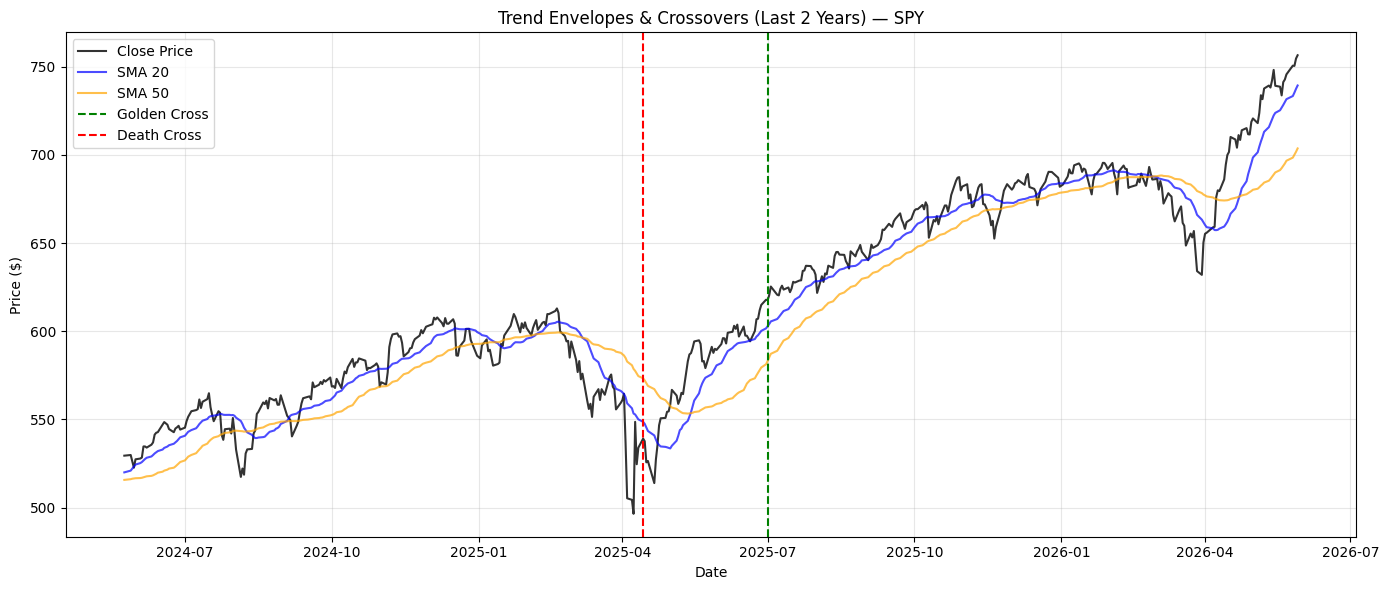

In [14]:
# TODO 1.2 — Plot close + SMA_20 + SMA_50 (last 2 years only)
# Mark Golden Cross (SMA_50 crosses above SMA_200) and Death Cross as vertical lines
# Hint: a cross occurs when the sign of (sma_50 - sma_200) changes

# Slice the last 2 full trading years (~504 trading sessions)
recent = df.tail(504).copy()

# Detect Crossovers on the full dataset first to prevent boundary slicing anomalies
cross_diff = df['sma_50'] - df['sma_200']
# A crossover occurs when the sign changes between consecutive periods
crossings = np.sign(cross_diff).diff().fillna(0) != 0

golden_crosses = df[(crossings) & (cross_diff > 0)].index
death_crosses  = df[(crossings) & (cross_diff < 0)].index

plt.figure(figsize=(14, 6))
plt.plot(recent.index, recent['close'], label='Close Price', color='black', alpha=0.8)
plt.plot(recent.index, recent['sma_20'], label='SMA 20', color='blue', alpha=0.7)
plt.plot(recent.index, recent['sma_50'], label='SMA 50', color='orange', alpha=0.7)

# Overlay Golden/Death cross structural lines if they occur within the 2-year frame
for gc in golden_crosses:
    if gc in recent.index:
        plt.axvline(gc, color='green', linestyle='--', linewidth=1.5, label='Golden Cross')
for dc in death_crosses:
    if dc in recent.index:
        plt.axvline(dc, color='red', linestyle='--', linewidth=1.5, label='Death Cross')

# Clear technical chart details
plt.title(f'Trend Envelopes & Crossovers (Last 2 Years) — {SYMBOL}')
plt.xlabel('Date')
plt.ylabel('Price ($)')
# Remove duplicate legend entries if multiple lines match identical labels
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Exponential Moving Average (EMA)

Assigns exponentially decaying weights to past prices — more reactive to recent moves than SMA.

$$k = \frac{2}{n+1}, \qquad \text{EMA}(t) = C_t \cdot k + \text{EMA}(t-1)\cdot(1-k)$$

Also compute:
$$\text{ema\_ratio}_{20} = \frac{C_t}{\text{EMA}_{20}(t)} - 1$$

In [15]:
# TODO 2.1 — Compute EMA_12, EMA_20, EMA_26 and ema_ratio_20
df['ema_12'] = df['close'].ewm(span=12, adjust=False).mean()
df['ema_20'] = df['close'].ewm(span=20, adjust=False).mean()
df['ema_26'] = df['close'].ewm(span=26, adjust=False).mean()

df['ema_ratio_20'] = (df['close'] / df['ema_20']) - 1

print("EMA series generated successfully.")

EMA series generated successfully.


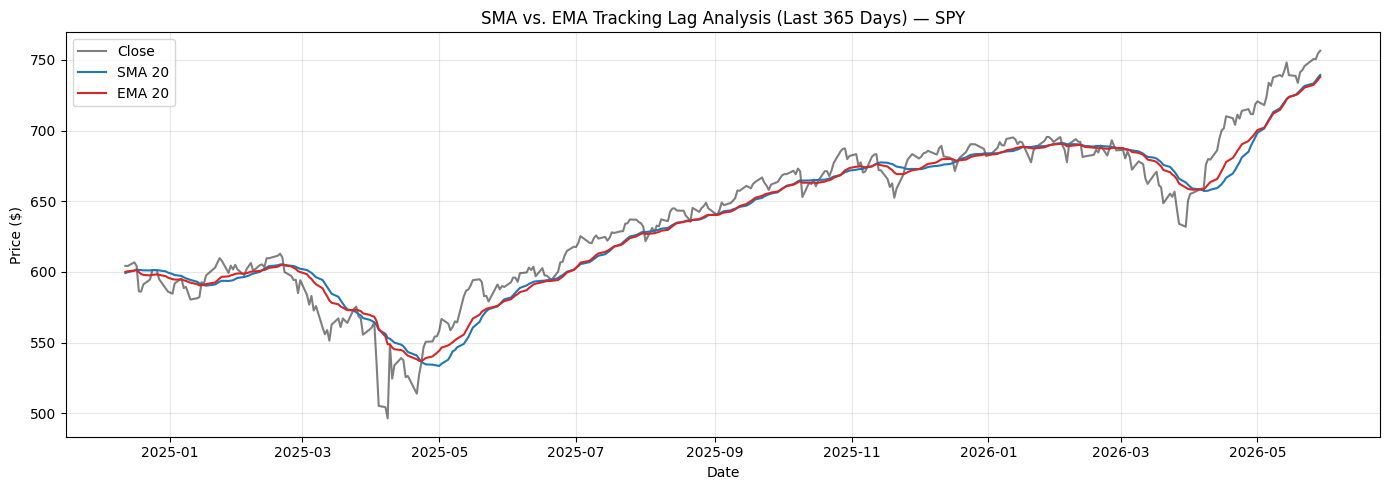

In [16]:
# TODO 2.2 — On a single chart, plot Close + SMA_20 + EMA_20 for the last 365 days
# Visually confirm: EMA reacts faster to price turns than SMA
recent_365 = df.tail(365)

plt.figure(figsize=(14, 5))
plt.plot(recent_365.index, recent_365['close'], label='Close', color='black', alpha=0.5)
plt.plot(recent_365.index, recent_365['sma_20'], label='SMA 20', color='tab:blue')
plt.plot(recent_365.index, recent_365['ema_20'], label='EMA 20', color='tab:red')

plt.title(f'SMA vs. EMA Tracking Lag Analysis (Last 365 Days) — {SYMBOL}')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Relative Strength Index (RSI)

Momentum oscillator bounded in $[0, 100]$. Measures the ratio of average gains to average losses over $n$ days.

$$\Delta_t = C_t - C_{t-1}$$
$$G_t = \max(\Delta_t,\,0), \quad L_t = |\min(\Delta_t,\,0)|$$
$$\overline{G}_n = \text{EMA}_n(G), \quad \overline{L}_n = \text{EMA}_n(L)$$
$$RS = \frac{\overline{G}_n}{\overline{L}_n}, \quad \text{RSI} = 100 - \frac{100}{1 + RS}$$

Wilder's RSI uses $\alpha = 1/n$ (i.e. `com = n-1`) rather than the standard EMA span. RSI $> 70$: overbought. RSI $< 30$: oversold. Normalise to $[0, 1]$ before storing as a model feature.

In [17]:
# TODO 3.1 — Implement RSI with window=14; store normalised (÷100) as 'rsi_14'
# Use Wilder smoothing: ewm(com=n-1, adjust=False)
delta = df['close'].diff()

# Separate gains and absolute losses explicitly
gain = delta.clip(lower=0)
loss = (-delta).clip(lower=0)

# Wilder's smoothing requires com = window - 1
window = 14
avg_gain = gain.ewm(com=window - 1, adjust=False).mean()
avg_loss = loss.ewm(com=window - 1, adjust=False).mean()

rs = avg_gain / avg_loss
rsi_raw = 100 - (100 / (1 + rs))

# Store as a feature normalized to a scalable model-ready range [0, 1]
df['rsi_14'] = rsi_raw / 100.0

print("Normalised Wilder's RSI-14 calculated.")

Normalised Wilder's RSI-14 calculated.


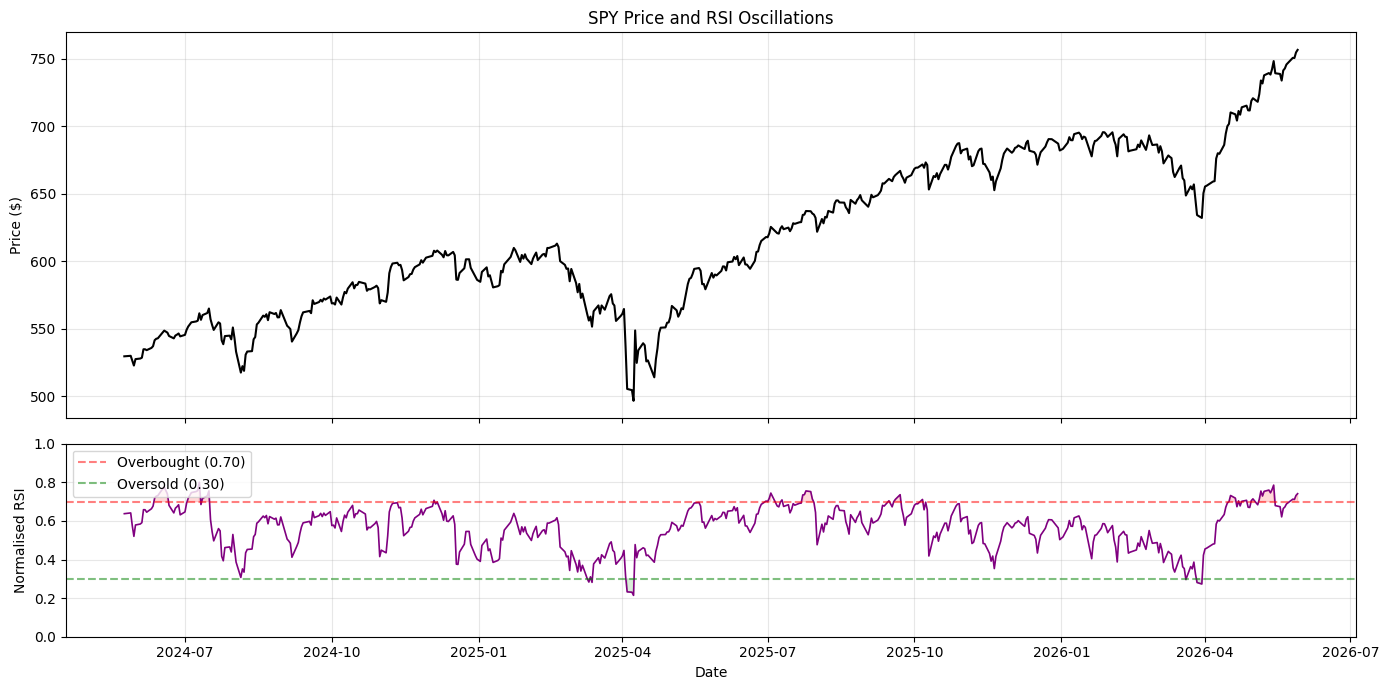

In [18]:
# TODO 3.2 — Two-panel chart: close (top) + RSI (bottom), sharex=True
# Dashed lines at 0.70 and 0.30; shade overbought in light red, oversold in light green
recent_rsi = df.tail(504)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# Top Chart - Close Price
ax1.plot(recent_rsi.index, recent_rsi['close'], color='black', linewidth=1.5)
ax1.set_title(f'{SYMBOL} Price and RSI Oscillations')
ax1.set_ylabel('Price ($)')
ax1.grid(True, alpha=0.3)

# Bottom Chart - Normalized RSI
ax2.plot(recent_rsi.index, recent_rsi['rsi_14'], color='purple', linewidth=1.2)
ax2.axhline(0.70, color='red', linestyle='--', alpha=0.5, label='Overbought (0.70)')
ax2.axhline(0.30, color='green', linestyle='--', alpha=0.5, label='Oversold (0.30)')

# Shading extreme zones matching conditions
ax2.fill_between(recent_rsi.index, recent_rsi['rsi_14'], 0.70, where=(recent_rsi['rsi_14'] >= 0.70), color='red', alpha=0.15)
ax2.fill_between(recent_rsi.index, recent_rsi['rsi_14'], 0.30, where=(recent_rsi['rsi_14'] <= 0.30), color='green', alpha=0.15)

ax2.set_ylabel('Normalised RSI')
ax2.set_ylim(0, 1)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.xlabel('Date')
plt.tight_layout()
plt.show()

## 4. MACD

Captures the convergence/divergence of two EMAs. Three outputs:

$$\text{MACD Line} = \text{EMA}_{12} - \text{EMA}_{26}$$
$$\text{Signal Line} = \text{EMA}_9(\text{MACD Line})$$
$$\text{Histogram} = \text{MACD Line} - \text{Signal Line}$$

Histogram sign-change → momentum shift. MACD crossing above Signal → bullish.

In [19]:
# TODO 4.1 — Compute macd, macd_signal, macd_hist using ema_12 and ema_26

df['macd']        = df['ema_12'] - df['ema_26']
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
df['macd_hist']   = df['macd'] - df['macd_signal']

print("MACD indicator array suite constructed.")

MACD indicator array suite constructed.


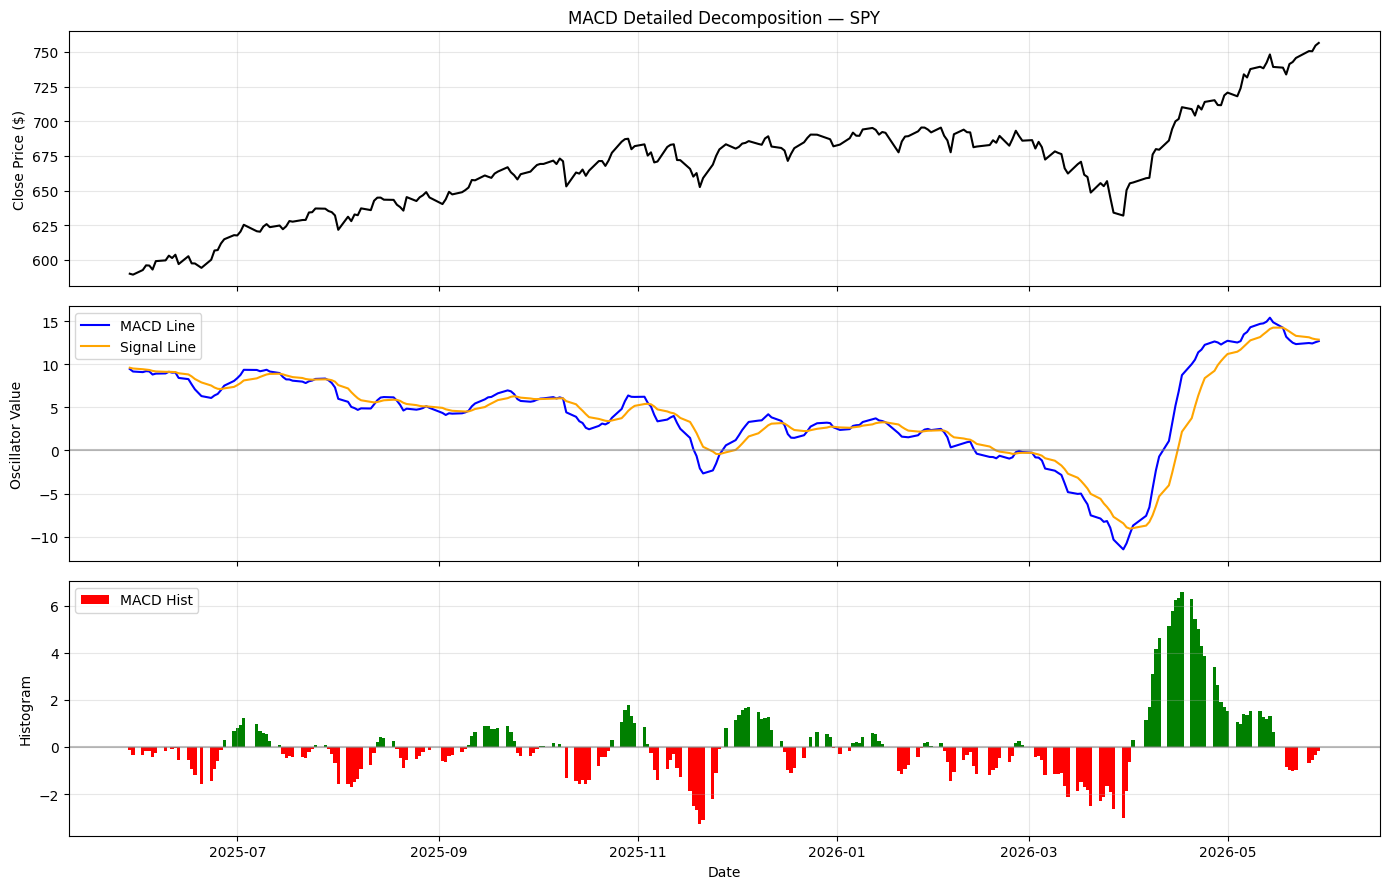

In [20]:
# TODO 4.2 — Three-panel chart: close | macd+signal | histogram coloured by sign
recent_macd = df.tail(252)  # Focus visual window on 1 trading year for readability

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# Panel 1: Close
ax1.plot(recent_macd.index, recent_macd['close'], color='black')
ax1.set_title(f'MACD Detailed Decomposition — {SYMBOL}')
ax1.set_ylabel('Close Price ($)')
ax1.grid(True, alpha=0.3)

# Panel 2: MACD + Signal Line
ax2.plot(recent_macd.index, recent_macd['macd'], label='MACD Line', color='blue')
ax2.plot(recent_macd.index, recent_macd['macd_signal'], label='Signal Line', color='orange')
ax2.axhline(0, color='gray', linestyle='-', alpha=0.5)
ax2.set_ylabel('Oscillator Value')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# Panel 3: Histogram with dynamic conditional matching colors
hist_colors = np.where(recent_macd['macd_hist'] >= 0, 'green', 'red')
ax3.bar(recent_macd.index, recent_macd['macd_hist'], color=hist_colors, width=1.0, label='MACD Hist')
ax3.axhline(0, color='gray', linestyle='-', alpha=0.5)
ax3.set_ylabel('Histogram')
ax3.legend(loc='upper left')
ax3.grid(True, alpha=0.3)

plt.xlabel('Date')
plt.tight_layout()
plt.show()

## 5. Bollinger Bands

Places volatility-scaled envelopes around the 20-day SMA.

$$\text{Upper} = \text{SMA}_{20} + k\cdot\sigma_{20}, \quad \text{Lower} = \text{SMA}_{20} - k\cdot\sigma_{20}, \quad k=2$$

Two derived features used as model inputs:

| Feature | Formula |
|---|---|
| **BB Width** | $\frac{\text{Upper} - \text{Lower}}{C_t}$ — proxy for volatility |
| **%B** | $\frac{C_t - \text{Lower}}{\text{Upper} - \text{Lower}}$ — position within bands |

In [21]:
# TODO 5 — Compute bb_upper, bb_lower, bb_width, bb_pct_b

rolling_std = df['close'].rolling(window=20).std()

df['bb_upper'] = df['sma_20'] + (2 * rolling_std)
df['bb_lower'] = df['sma_20'] - (2 * rolling_std)

# Derived volatility proxy attributes
df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / df['close']
# %B feature metrics position calculation
df['bb_pct_b'] = (df['close'] - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'])
# Safe bounding to clean outer flash variance tail spikes
df['bb_pct_b'] = df['bb_pct_b'].clip(0.0, 1.0)

print("Bollinger Band parameters locked.")

Bollinger Band parameters locked.


## 6. Rate of Change (ROC)

Measures momentum as the percentage change over $n$ periods.

$$\text{ROC}_n(t) = \frac{C_t - C_{t-n}}{C_{t-n}} \times 100$$

Compute for $n = 5$ and $n = 10$.

In [22]:
# TODO 6 — Compute roc_5 and roc_10
df['roc_5']  = ((df['close'] - df['close'].shift(5)) / df['close'].shift(5)) * 100
df['roc_10'] = ((df['close'] - df['close'].shift(10)) / df['close'].shift(10)) * 100

print("Rate of Change dimensions calculated.")

Rate of Change dimensions calculated.


## 7. Average True Range (ATR)

Measures volatility using all three price extremes. Unlike rolling return std, ATR accounts for overnight gaps.

$$TR_t = \max\bigl(H_t - L_t,\;|H_t - C_{t-1}|,\;|L_t - C_{t-1}|\bigr)$$

$$\text{ATR}_{14}(t) = \text{EMA}_{14}(TR) \quad\text{(Wilder smoothing: }\alpha = 1/n\text{)}$$

Normalise by close to make it comparable across symbols:
$$\text{atr\_ratio} = \frac{\text{ATR}_{14}}{C_t}$$

In [23]:
# TODO 7 — Compute true_range, atr_14, atr_ratio
# Use Wilder smoothing (ewm with com=13, adjust=False)

prev_close = df['close'].shift(1)

# Calculate components for true range calculation formula
tr1 = df['high'] - df['low']
tr2 = (df['high'] - prev_close).abs()
tr3 = (df['low'] - prev_close).abs()

# Find the maximum true range across all components horizontally
true_range = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

# Apply Wilder smoothing criteria to the raw TR vector
df['atr_14']    = true_range.ewm(com=13, adjust=False).mean()
df['atr_ratio'] = df['atr_14'] / df['close']

print("Volatility scaling parameters (ATR) extracted.")

Volatility scaling parameters (ATR) extracted.


## 8. Stochastic Oscillator (%K and %D)

Compares the closing price to the price range over a lookback window.

$$\%K_n(t) = \frac{C_t - \min_n(L)}{\max_n(H) - \min_n(L)} \times 100$$

$$\%D = \text{SMA}_3(\%K) \quad \text{(signal smoothing)}$$

Use $n = 14$. Normalise both to $[0, 1]$. Store as `stoch_k` and `stoch_d`.

In [24]:
# TODO 8.1 — Compute stoch_k and stoch_d
lowest_low   = df['low'].rolling(window=14).min()
highest_high = df['high'].rolling(window=14).max()

# Compute raw %K bound inside [0, 100] scale bounds
stoch_k_raw = ((df['close'] - lowest_low) / (highest_high - lowest_low)) * 100
stoch_d_raw = stoch_k_raw.rolling(window=3).mean()

# Standardise down into the uniform [0, 1] feature input layout
df['stoch_k'] = stoch_k_raw / 100.0
df['stoch_d'] = stoch_d_raw / 100.0

print("Stochastic tracking attributes created.")

Stochastic tracking attributes created.


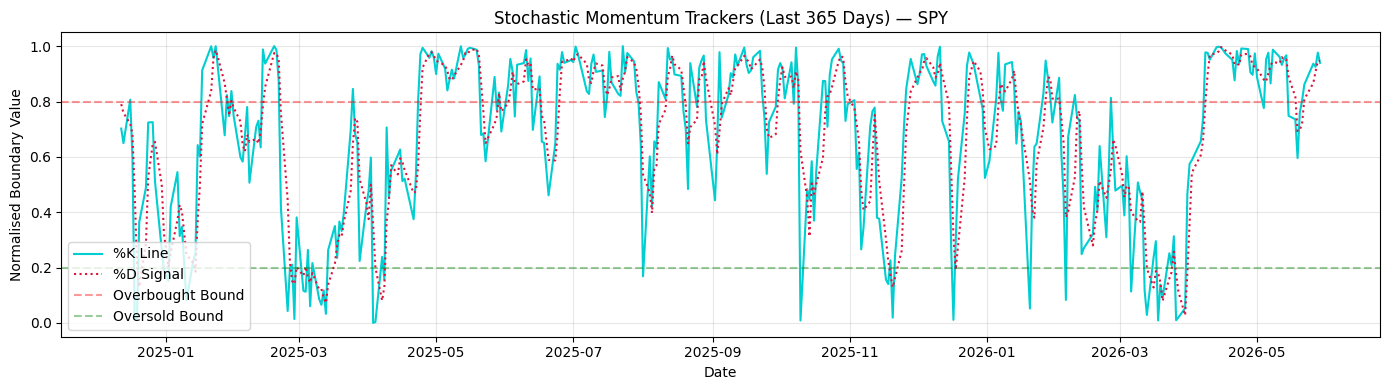

In [25]:
# TODO 8.2 — Plot stoch_k and stoch_d, last 365 days
# Mark 0.80 and 0.20 thresholds
# When %K crosses above %D from below the oversold zone → classic buy signal
recent_stoch = df.tail(365)

plt.figure(figsize=(14, 4))
plt.plot(recent_stoch.index, recent_stoch['stoch_k'], label='%K Line', color='darkturquoise')
plt.plot(recent_stoch.index, recent_stoch['stoch_d'], label='%D Signal', color='crimson', linestyle=':')
plt.axhline(0.80, color='red', linestyle='--', alpha=0.4, label='Overbought Bound')
plt.axhline(0.20, color='green', linestyle='--', alpha=0.4, label='Oversold Bound')

plt.title(f'Stochastic Momentum Trackers (Last 365 Days) — {SYMBOL}')
plt.ylabel('Normalised Boundary Value')
plt.xlabel('Date')
plt.ylim(-0.05, 1.05)
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. On-Balance Volume (OBV)

Cumulative volume indicator — adds volume on up-days, subtracts it on down-days. Used to detect whether volume confirms or diverges from a price trend.

$$\text{OBV}(t) = \text{OBV}(t-1) + \begin{cases} +V_t & C_t > C_{t-1} \\ -V_t & C_t < C_{t-1} \\ 0 & C_t = C_{t-1} \end{cases}$$

Store the **percentage change** of OBV as the model feature: $\text{obv\_change} = \frac{\text{OBV}(t) - \text{OBV}(t-1)}{|\text{OBV}(t-1)|}$

In [26]:
# TODO 9 — Compute obv and obv_change
# np.sign(close.diff()) gives +1 / 0 / -1 for each day's direction

direction = np.sign(df['close'].diff()).fillna(0)
# Volume allocation based on daily direction signs
volume_weighted = df['volume'].fillna(0) * direction

df['obv']        = volume_weighted.cumsum()
df['obv_change'] = df['obv'].pct_change().fillna(0)

# Replace any theoretical infinite variants from zero division issues
df['obv_change'] = df['obv_change'].replace([np.inf, -np.inf], 0.0)

print("On-Balance Volume structures built.")

On-Balance Volume structures built.


## 10. Volume-Weighted Average Price (VWAP)

The price level weighted by volume — a fair-value benchmark widely used by institutional traders.

We compute a **rolling 20-day VWAP** using the typical price:

$$P_{\text{typ}}(t) = \frac{H_t + L_t + C_t}{3}$$

$$\text{VWAP}_{20}(t) = \frac{\sum_{i=0}^{19} P_{\text{typ}}(t{-}i)\cdot V_{t{-}i}}{\sum_{i=0}^{19} V_{t{-}i}}$$

Normalise: $\text{vwap\_ratio} = C_t / \text{VWAP} - 1$

In [27]:
# TODO 10 — Compute rolling VWAP (20-day) and vwap_ratio

typical_price = (df['high'] + df['low'] + df['close']) / 3.0
tp_vol        = typical_price * df['volume'].fillna(0)

rolling_tp_vol = tp_vol.rolling(window=20).sum()
rolling_volume = df['volume'].fillna(0).rolling(window=20).sum()

df['vwap']        = rolling_tp_vol / rolling_volume
df['vwap_ratio'] = (df['close'] / df['vwap']) - 1

print("Volume-Weighted average price arrays resolved.")

Volume-Weighted average price arrays resolved.


## 11. Build & Save the Feature Dataset

Combine all indicators into a clean DataFrame and save to `data/processed/`.
This CSV will be loaded directly by the model notebooks in later weeks.

In [28]:
FEATURE_COLUMNS = [
    'return_1', 'return_5', 'log_return_1',
    'sma_ratio_20', 'sma_ratio_50',
    'ema_ratio_20',
    'rsi_14',
    'macd', 'macd_signal',
    'roc_5', 'roc_10',
    'bb_width', 'bb_pct_b',
    'atr_ratio',
    'stoch_k', 'stoch_d',
    'obv_change',
    'vwap_ratio',
]

In [30]:
# TODO 11.1 — Add target columns, clean, and save
# 'future_return'    = next-day return  (close shifted -1 divided by close, minus 1)
# 'target_direction' = 1 if future_return > 0, else 0
#
# Then:
#   1. Replace inf / -inf with NaN
#   2. Drop rows where ANY required column is NaN
#   3. Reset index so 'date' becomes a regular column again
#   4. Save to  PROCESSED_DIR / f'{safe_symbol(SYMBOL)}_features.csv'
#   5. Print the output path and shape; show .describe() of required columns

df['future_return']    = (df['close'].shift(-1) / df['close']) - 1
df['target_direction'] = np.where(df['future_return'] > 0, 1, 0)

# 1. Replace structural infinite bounds with NaN rows
df = df.replace([np.inf, -np.inf], np.nan)

# 2. Extract only required data matrix columns
all_required_cols = FEATURE_COLUMNS + ['future_return', 'target_direction']
df_clean = df[all_required_cols].dropna().copy()

# 3. Convert the timestamp from index into an explicit file data column
df_clean = df_clean.reset_index()

# 4. Save to target processed folder destination
out_path = PROCESSED_DIR / f"{safe_symbol(SYMBOL)}_features.csv"
df_clean.to_csv(out_path, index=False)

print(f"File stored successfully at: {out_path}")
print(f"Clean Matrix Shape Profile : {df_clean.shape}")

# 5. Output concise quantitative data description checks
df_clean[all_required_cols].describe().round(4)

File stored successfully at: /content/drive/MyDrive/MarketTradingCourse/data/processed/SPY_features.csv
Clean Matrix Shape Profile : (2818, 21)


,return_1,return_5,log_return_1,sma_ratio_20,sma_ratio_50,ema_ratio_20,rsi_14,macd,macd_signal,roc_5,roc_10,bb_width,bb_pct_b,atr_ratio,stoch_k,stoch_d,obv_change,vwap_ratio,future_return,target_direction
count,2818.0000,2818.0000,2818.0000,2818.0000,2818.0000,2818.0000,2818.0000,2818.0000,2818.0000,2818.0000,2818.0000,2818.0000,2818.0000,2818.0000,2818.0000,2818.0000,2818.0000,2818.0000,2818.0000,2818.0000
mean,0.0005,0.0026,0.0005,0.0044,0.0112,0.0042,0.5567,1.2742,1.2569,0.2557,0.5043,0.0635,0.6069,0.0126,0.6544,0.6541,-0.0436,0.0068,0.0005,0.5468
std,0.0112,0.0229,0.0112,0.0249,0.0376,0.0211,0.1138,4.1838,3.8898,2.2931,3.1613,0.0464,0.2993,0.0067,0.3010,0.2780,3.1560,0.0241,0.0112,0.4979
min,-0.1094,-0.1797,-0.1159,-0.2008,-0.2782,-0.1784,0.1698,-23.7868,-19.8942,-17.9693,-23.2884,0.0097,0.0000,0.0037,0.0000,0.0138,-136.3902,-0.1815,-0.1094,0.0000
25%,-0.0037,-0.0073,-0.0037,-0.0058,-0.0046,-0.0044,0.4783,-0.3946,-0.3218,-0.7336,-0.8179,0.0366,0.3803,0.0085,0.4330,0.4370,-0.0896,-0.0039,-0.0037,0.0000
50%,0.0006,0.0040,0.0006,0.0082,0.0180,0.0082,0.5718,1.6338,1.6636,0.4027,0.7593,0.0526,0.6911,0.0107,0.7459,0.7468,-0.0291,0.0094,0.0006,1.0000
75%,0.0059,0.0146,0.0059,0.0184,0.0345,0.0167,0.6404,3.6061,3.4044,1.4554,2.2532,0.0754,0.8499,0.0153,0.9205,0.9010,0.0843,0.0198,0.0059,1.0000
max,0.1050,0.1736,0.0999,0.1136,0.1325,0.0680,0.8703,15.4243,14.2691,17.3582,18.7979,0.5538,1.0000,0.0661,1.0000,0.9994,56.9382,0.1316,0.1050,1.0000


In [31]:
# TODO 11.2 (Challenge) — Run the full pipeline for ALL downloaded symbols
# Loop over every CSV in RAW_DIR, compute all indicators, save to PROCESSED_DIR.
# Wrap each symbol in try/except so one failure does not stop the loop.
# Print a summary table at the end with columns:
#   symbol | rows_raw | rows_processed | drop_pct

summary = []

for csv_path in RAW_DIR.glob('*.csv'):
    # Deriving ticker identification labels from the file stem layout names
    sym_stem = csv_path.stem

    try:
        # Load and clean structural row indices
        raw_df = pd.read_csv(csv_path)
        raw_df['date'] = pd.to_datetime(raw_df['date'])
        raw_df = raw_df.sort_values('date').set_index('date')

        # Guard zero allocation volumes
        raw_df.loc[raw_df['volume'] == 0, 'volume'] = np.nan

        # Extract operational shorthand references
        c  = raw_df['close']
        h  = raw_df['high']
        l  = raw_df['low']
        v  = raw_df['volume']
        pc = c.shift(1)

        # --- Run Complete Technical Core Indicators Calculations Engine ---
        raw_df['return_1']     = c.pct_change(1)
        raw_df['return_5']     = c.pct_change(5)
        raw_df['log_return_1'] = np.log(c / c.shift(1))

        raw_df['sma_20']       = c.rolling(window=20).mean()
        raw_df['sma_50']       = c.rolling(window=50).mean()
        raw_df['sma_ratio_20'] = (c / raw_df['sma_20']) - 1
        raw_df['sma_ratio_50'] = (c / raw_df['sma_50']) - 1

        raw_df['ema_12']       = c.ewm(span=12, adjust=False).mean()
        raw_df['ema_20']       = c.ewm(span=20, adjust=False).mean()
        raw_df['ema_26']       = c.ewm(span=26, adjust=False).mean()
        raw_df['ema_ratio_20'] = (c / raw_df['ema_20']) - 1

        delta = c.diff()
        gain  = delta.clip(lower=0)
        loss  = (-delta).clip(lower=0)
        raw_df['rsi_14'] = (gain.ewm(com=13, adjust=False).mean() / loss.ewm(com=13, adjust=False).mean())
        raw_df['rsi_14'] = (100 - (100 / (1 + raw_df['rsi_14']))) / 100.0

        raw_df['macd']        = raw_df['ema_12'] - raw_df['ema_26']
        raw_df['macd_signal'] = raw_df['macd'].ewm(span=9, adjust=False).mean()
        raw_df['macd_hist']   = raw_df['macd'] - raw_df['macd_signal']

        r_std = c.rolling(window=20).std()
        raw_df['bb_width'] = ((raw_df['sma_20'] + (2*r_std)) - (raw_df['sma_20'] - (2*r_std))) / c
        raw_df['bb_pct_b'] = ((c - (raw_df['sma_20'] - (2*r_std))) / ((raw_df['sma_20'] + (2*r_std)) - (raw_df['sma_20'] - (2*r_std)))).clip(0, 1)

        raw_df['roc_5']  = ((c - c.shift(5)) / c.shift(5)) * 100
        raw_df['roc_10'] = ((c - c.shift(10)) / c.shift(10)) * 100

        tr = pd.concat([h-l, (h-pc).abs(), (l-pc).abs()], axis=1).max(axis=1)
        raw_df['atr_ratio'] = tr.ewm(com=13, adjust=False).mean() / c

        sk = ((c - l.rolling(14).min()) / (h.rolling(14).max() - l.rolling(14).min()))
        raw_df['stoch_k'] = sk.clip(0, 1)
        raw_df['stoch_d'] = raw_df['stoch_k'].rolling(3).mean()

        obv_v = v.fillna(0) * np.sign(c.diff()).fillna(0)
        raw_df['obv']        = obv_v.cumsum()
        raw_df['obv_change'] = raw_df['obv'].pct_change().fillna(0).replace([np.inf, -np.inf], 0)

        tp = (h + l + c) / 3.0
        raw_df['vwap_ratio'] = (c / (tp * v.fillna(0)).rolling(20).sum() / v.fillna(0).rolling(20).sum()) - 1

        # --- Target Definition and Post-Processing ---
        raw_df['future_return']    = (c.shift(-1) / c) - 1
        raw_df['target_direction'] = np.where(raw_df['future_return'] > 0, 1, 0)

        raw_df = raw_df.replace([np.inf, -np.inf], np.nan)
        proc_df = raw_df[all_required_cols].dropna().reset_index()

        # Save output
        proc_df.to_csv(PROCESSED_DIR / f"{sym_stem}_features.csv", index=False)

        # Keep track of execution health statistics
        rows_raw  = len(raw_df)
        rows_proc = len(proc_df)
        drop_pct  = ((rows_raw - rows_proc) / rows_raw) * 100

        summary.append({
            'symbol': sym_stem,
            'rows_raw': rows_raw,
            'rows_processed': rows_proc,
            'drop_pct': round(drop_pct, 2)
        })
    except Exception as e:
        summary.append({'symbol': sym_stem, 'error': str(e)})

# Output final summary status framework
pd.DataFrame(summary)

,symbol,rows_raw,rows_processed,drop_pct
0,NSEI,2806,2756,1.78
1,BSESN,2805,2755,1.78
2,RELIANCE_NS,2817,2767,1.77
3,TCS_NS,2817,2767,1.77
4,INFY_NS,2817,2767,1.77
5,GSPC,2868,2818,1.74
6,IXIC,2868,2818,1.74
7,SPY,2868,2818,1.74
8,AAPL,2868,2818,1.74
9,MSFT,2868,2818,1.74


---
